# XGBoost — DC Current Prediction (Power Limiter)

**Goal:** 1-step-ahead prediction of DC bus current (10 ms horizon) for the 80 kW power limiter.

**Approach:** Supervised regression on lag features — XGBoost sees the last N ticks of current,
torque setpoints and voltage, and predicts `I_dc(t+1)`.

**Features:** `[I_dc(t), I_dc(t-1), ..., T_sum(t), T_sum(t-1), ..., U_v(t)]`  
**Target:** `I_dc(t+1)`  
**Split:** first 70% train, last 30% test (temporal order preserved)

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

# --- Local paths ---
_cwd = Path().resolve()
if (_cwd / 'functions').exists():
    SRC_DIR = _cwd
elif (_cwd / 'src' / 'functions').exists():
    SRC_DIR = _cwd / 'src'
else:
    raise FileNotFoundError(f'Could not find functions/ in {_cwd} or {_cwd}/src/')

DATA_DIR = SRC_DIR.parent / 'data' / 'model'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from functions.evaluation import display_model_results

# --- Constants ---
DT_VCU        = 0.010
POWER_LIMIT_W = 80_000
GAP_THRESHOLD = 0.100
N_LAGS        = 10       # history window: 10 ticks = 100 ms

print('Imports OK.')
print(f'XGBoost version : {xgb.__version__}')
print(f'DATA_DIR        : {DATA_DIR}')
print(f'Lag window      : {N_LAGS} ticks = {N_LAGS*DT_VCU*1000:.0f} ms')

Imports OK.
XGBoost version : 3.2.0
DATA_DIR        : /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/data/model
Lag window      : 10 ticks = 100 ms


## 1. Data Loading and VCU Grid

In [2]:
# DC current + voltage
df_raw = pd.read_csv(DATA_DIR / 'fsp_endu_current.csv')
df_raw.columns = ['t', 'I_dc', 'U_raw']
df_raw['U_v']  = df_raw['U_raw'] / 10.0
df_raw = df_raw.sort_values('t').reset_index(drop=True)
df_raw['dt'] = df_raw['t'].diff().fillna(0)

# Motor torque setpoints (FR, RL, RR)
df_sp = pd.read_csv(DATA_DIR / 'setpoints.csv')
df_sp.columns = ['t', 'T_FR', 'T_RL', 'T_RR']

# VCU 10 ms grid
t_vcu = np.arange(df_raw['t'].min(), df_raw['t'].max(), DT_VCU)

df = pd.DataFrame({'t': t_vcu})
df['I_dc'] = np.interp(t_vcu, df_raw['t'].values, df_raw['I_dc'].values)
df['U_v']  = np.interp(t_vcu, df_raw['t'].values, df_raw['U_v'].values)
for col in ['T_FR', 'T_RL', 'T_RR']:
    df[col] = np.interp(t_vcu, df_sp['t'].values, df_sp[col].values)
df['T_sum'] = df['T_FR'] + df['T_RL'] + df['T_RR']

print(f'VCU ticks : {len(df):,}  ({df["t"].max():.1f} s)')
print(f'I_dc range: {df["I_dc"].min():.0f} .. {df["I_dc"].max():.0f} A')
df.head()

VCU ticks : 58,099  (581.0 s)
I_dc range: -101 .. 1357 A


,t,I_dc,U_v,T_FR,T_RL,T_RR,T_sum
0,0.010176,0.0,535.6,0.0,0.0,0.0,0.0
1,0.020176,0.0,535.6,0.0,0.0,0.0,0.0
2,0.030176,0.0,535.6,0.0,0.0,0.0,0.0
3,0.040176,0.0,535.6,0.0,0.0,0.0,0.0
4,0.050176,0.0,535.6,0.0,0.0,0.0,0.0


## 2. Feature Engineering

For each tick `t`, build a feature vector from the past `N_LAGS` ticks:

| Group | Features |
|-------|----------|
| Current history | `I_dc(t), I_dc(t-1), ..., I_dc(t-N+1)` |
| Setpoint history | `T_sum(t), T_sum(t-1), ..., T_sum(t-N+1)` |
| Voltage | `U_v(t)` |
| Derived | `dI_dt(t)` = finite difference |

**Target:** `I_dc(t+1)` — current one tick (10 ms) into the future.

In [3]:
feature_cols = []

# Lagged current
for lag in range(N_LAGS):
    col = f'I_dc_lag{lag}'
    df[col] = df['I_dc'].shift(lag)
    feature_cols.append(col)

# Lagged total torque setpoint
for lag in range(N_LAGS):
    col = f'T_sum_lag{lag}'
    df[col] = df['T_sum'].shift(lag)
    feature_cols.append(col)

# Voltage (slow-changing, no lag needed)
df['U_v_feat'] = df['U_v']
feature_cols.append('U_v_feat')

# Current derivative (finite difference)
df['dI_dt'] = df['I_dc'].diff().fillna(0) / DT_VCU
feature_cols.append('dI_dt')

# Target: I_dc one step ahead
df['target'] = df['I_dc'].shift(-1)

# Drop rows with NaN (from lag/shift)
df_clean = df.dropna().reset_index(drop=True)

print(f'Feature count  : {len(feature_cols)}')
print(f'Feature names  : {feature_cols[:5]} ... {feature_cols[-3:]}')
print(f'Rows after dropna: {len(df_clean):,}')

Feature count  : 22
Feature names  : ['I_dc_lag0', 'I_dc_lag1', 'I_dc_lag2', 'I_dc_lag3', 'I_dc_lag4'] ... ['T_sum_lag9', 'U_v_feat', 'dI_dt']
Rows after dropna: 58,089


## 3. Train / Test Split

Same 70 / 30 temporal split as the EKF notebook — no shuffling to preserve time order.

In [4]:
n_train = int(len(df_clean) * 0.70)

X_train = df_clean[feature_cols].iloc[:n_train].values
y_train = df_clean['target'].iloc[:n_train].values

X_test  = df_clean[feature_cols].iloc[n_train:].values
y_test  = df_clean['target'].iloc[n_train:].values

U_test  = df_clean['U_v'].iloc[n_train:].values
t_test  = df_clean['t'].iloc[n_train:].values

print(f'Train samples : {len(X_train):,}  ({len(X_train)*DT_VCU:.1f} s)')
print(f'Test samples  : {len(X_test):,}   ({len(X_test)*DT_VCU:.1f} s)')
print(f'X_train shape : {X_train.shape}')

Train samples : 40,662  (406.6 s)
Test samples  : 17,427   (174.3 s)
X_train shape : (40662, 22)


## 4. XGBoost Training

Quick random search over key hyperparameters, then retrain best config on full train set.

In [5]:
param_grid = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
}

base_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
t_train = time.perf_counter() - t0

print(f'\nSearch complete in {t_train:.1f} s')
print(f'Best RMSE (CV) : {-search.best_score_:.2f} A')
print(f'Best params    : {search.best_params_}')

model = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Search complete in 16.7 s
Best RMSE (CV) : 10.05 A
Best params    : {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


## 5. Evaluation

  MODEL: XGBoost — 1-step DC current
  R2              : 0.9991
  RMSE            : 8.43 A
  MAE             : 4.27 A
  MedAE           : 2.05 A
  MAPE            : 3.72 %
  R2 per motor    : I_DC=0.999
--------------------------------------------------------
  Under-pred.     : 49.7 % of samples
  Mean under-pred.: 4.61 A   (dangerous direction!)
--------------------------------------------------------
  Power RMSE      : 4.13 kW
  Real violations : 10576 events > 80 kW
  Missed (FN)     : 35   <- CRITICAL
  Unnecessary (FP): 27
  Violation recall: 99.7 %
--------------------------------------------------------
  Time/sample     : 0.0021 ms
  Frequency       : 477981.8 Hz



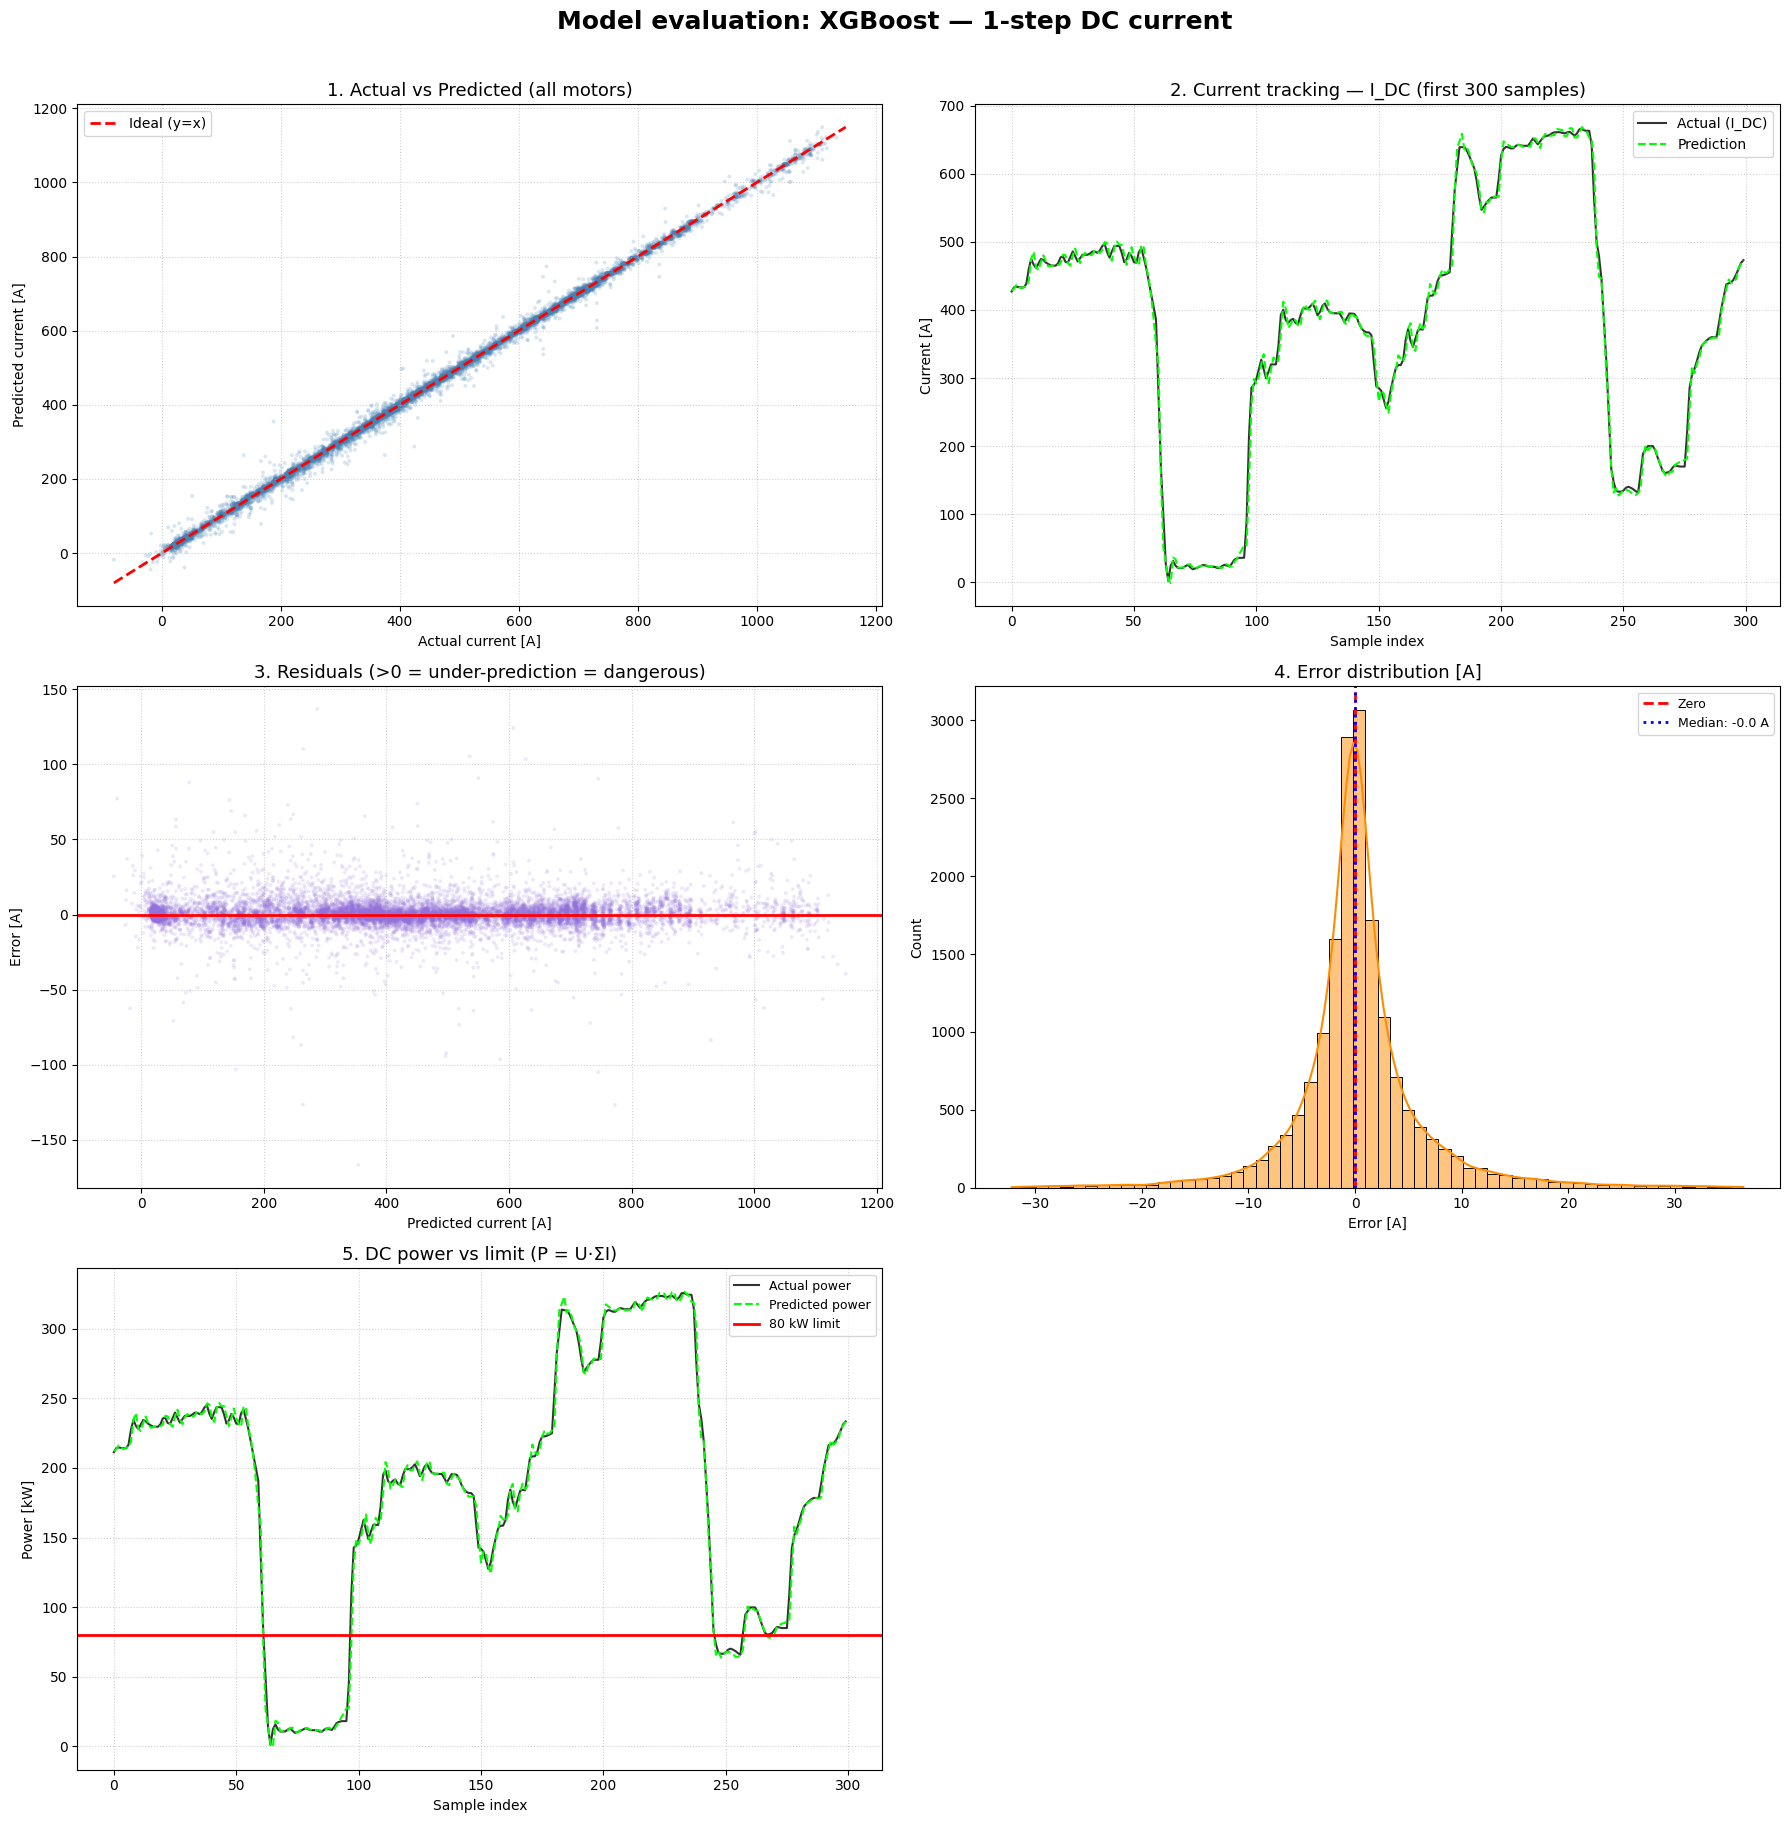

In [6]:
t0 = time.perf_counter()
y_pred = model.predict(X_test)
t_infer = time.perf_counter() - t0

metrics = display_model_results(
    model_name='XGBoost — 1-step DC current',
    y_true=y_test,
    y_pred=y_pred,
    inference_time=t_infer,
    voltage=U_test,
    motor_names=['I_DC'],
    save_to_excel=False,
)

## 6. Feature Importance

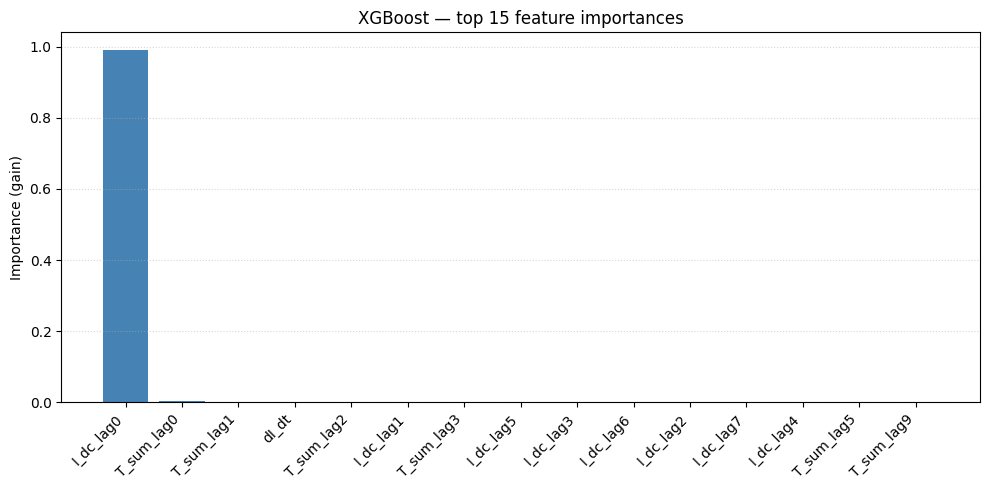

Top 5 features:
  I_dc_lag0           importance=0.9910
  T_sum_lag0          importance=0.0023
  T_sum_lag1          importance=0.0018
  dI_dt               importance=0.0010
  T_sum_lag2          importance=0.0008


In [7]:
importances = model.feature_importances_
idx = np.argsort(importances)[::-1]
top_n = 15

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(top_n), importances[idx[:top_n]], color='steelblue')
ax.set_xticks(range(top_n))
ax.set_xticklabels([feature_cols[i] for i in idx[:top_n]], rotation=45, ha='right')
ax.set_title(f'XGBoost — top {top_n} feature importances', fontsize=12)
ax.set_ylabel('Importance (gain)')
ax.grid(True, ls=':', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

print('Top 5 features:')
for i in idx[:5]:
    print(f'  {feature_cols[i]:<18}  importance={importances[i]:.4f}')

## 7. Visualization

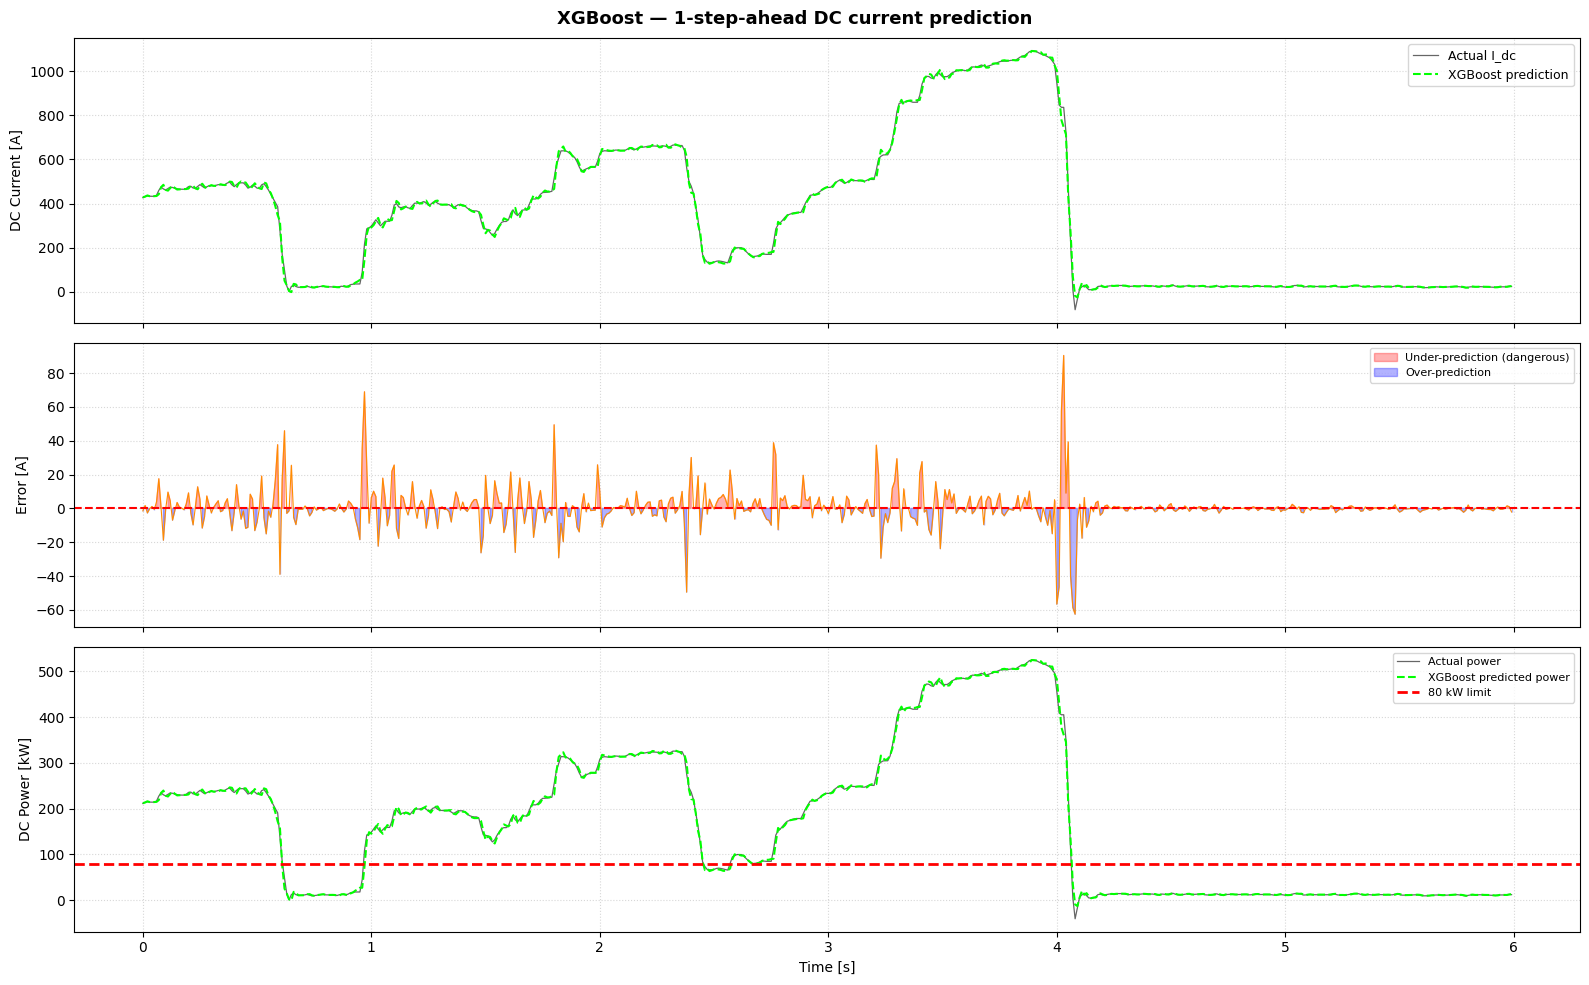

In [8]:
N_PLOT = 600
sl = slice(0, N_PLOT)
t_plot = t_test[sl] - t_test[0]

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('XGBoost — 1-step-ahead DC current prediction', fontsize=13, fontweight='bold')

# Panel 1: actual vs predicted
ax = axes[0]
ax.plot(t_plot, y_test[sl],  lw=0.9, color='black', alpha=0.6, label='Actual I_dc')
ax.plot(t_plot, y_pred[sl],  lw=1.5, color='lime',  ls='--',   label='XGBoost prediction')
ax.set_ylabel('DC Current [A]')
ax.legend(fontsize=9)
ax.grid(True, ls=':', alpha=0.5)

# Panel 2: prediction error
ax = axes[1]
err = y_test[sl] - y_pred[sl]
ax.plot(t_plot, err, lw=0.8, color='darkorange')
ax.axhline(0, color='red', lw=1.5, ls='--')
ax.fill_between(t_plot, err, 0, where=(err > 0), alpha=0.3, color='red',  label='Under-prediction (dangerous)')
ax.fill_between(t_plot, err, 0, where=(err < 0), alpha=0.3, color='blue', label='Over-prediction')
ax.set_ylabel('Error [A]')
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.5)

# Panel 3: DC power vs 80 kW limit
ax = axes[2]
U_sl   = U_test[sl]
P_true = U_sl * y_test[sl] / 1e3
P_pred = U_sl * y_pred[sl] / 1e3
ax.plot(t_plot, P_true, lw=0.9, color='black', alpha=0.6, label='Actual power')
ax.plot(t_plot, P_pred, lw=1.5, color='lime',  ls='--',   label='XGBoost predicted power')
ax.axhline(80, color='red', lw=2, ls='--', label='80 kW limit')
ax.set_ylabel('DC Power [kW]')
ax.set_xlabel('Time [s]')
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Summary

| Property | Value |
|---|---|
| Model | XGBoost (tree ensemble) |
| Features | lagged I_dc, T_sum, U_v + dI/dt |
| Lag window | 10 ticks = 100 ms |
| Prediction horizon | 1 tick = 10 ms |
| VCU suitability | batch predict on fixed feature vector — fast |

**Next:** compare XGBoost vs EKF 3-state in notebook `04_model_comparison.ipynb`.